# ประเมินผลระบบอ่านป้ายทะเบียนรถ (License Plate OCR Evaluation Report)

โน้ตบุ๊กนี้ใช้สำหรับประเมินความแม่นยำ (Accuracy) ของระบบอ่านป้ายทะเบียนรถ โดยเทียบผลลัพธ์ที่ระบบทำนายกับไฟล์เฉลย (Ground Truth) แบ่งการประเมินออกเป็น 3 ส่วนคือ

1. ความแม่นยำแบบรวม (ถูกทั้งเลขทะเบียนและจังหวัด)
2. ความแม่นยำเฉพาะเลขทะเบียน
3. ความแม่นยำเฉพาะจังหวัด

นอกจากนี้ยังมีการวิเคราะห์ **ตัวอักษร/ตัวเลขที่ระบบทายผิดบ่อย** (Confusion Analysis) เพื่อดูว่าตัวจริงถูกทายผิดเป็นตัวใดบ่อยที่สุด

> **ข้อกำหนดก่อนรัน:** ต้องมีไฟล์ `plate_reader.py` (โมดูลอ่านป้ายทะเบียนที่ใช้ pipeline เดียวกับระบบจริง ตั้งแต่ YOLO #2 จนถึง OCR/output) อยู่ในโฟลเดอร์เดียวกับโน้ตบุ๊กนี้ หรือแก้ตัวแปร `MODULE_DIR` ในเซลล์ถัดไปให้ชี้ไปยัง path ที่ถูกต้อง ต้องมีไฟล์โมเดล YOLO #2 (`model/yolo2/best.onnx`) อยู่ในตำแหน่งที่ `plate_reader.py` อ้างถึง และต้องมีไฟล์เฉลย (ground truth CSV) รูปแบบคอลัมน์ `file,plate_number,province`


## 1. นำเข้าไลบรารีและโมดูลที่จำเป็น


In [1]:
import sys
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

# rapidfuzz ใช้คำนวณ Levenshtein edit distance และจัดตำแหน่ง (alignment) ตัวอักษรสำหรับหาคู่ที่ทายผิด
from rapidfuzz.distance import Levenshtein

# ---- ตั้งค่าฟอนต์ภาษาไทยสำหรับกราฟ matplotlib ----
THAI_FONT_CANDIDATES = ["Tahoma", "Leelawadee UI", "TH Sarabun New", "Angsana New", "Norasi"]
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
for _f in THAI_FONT_CANDIDATES:
    if _f in available_fonts:
        plt.rcParams["font.family"] = _f
        break
else:
    print("⚠️  ไม่พบฟอนต์ไทยในเครื่อง กราฟอาจแสดงภาษาไทยไม่ถูกต้อง แนะนำติดตั้งฟอนต์ เช่น TH Sarabun New")
plt.rcParams["axes.unicode_minus"] = False


## 2. นำเข้าฟังก์ชันจากระบบอ่านป้ายทะเบียนเดิม (`plate_reader.py`)

แก้ `MODULE_DIR` ด้านล่างให้ชี้ไปยังโฟลเดอร์ที่เก็บไฟล์ `plate_reader.py` (ถ้าอยู่โฟลเดอร์เดียวกับโน้ตบุ๊กนี้ ไม่ต้องแก้)


In [2]:
MODULE_DIR = Path.cwd()   # <-- แก้ path ตรงนี้ถ้า plate_reader_4.py อยู่คนละโฟลเดอร์
sys.path.append(str(MODULE_DIR))

# read_plate() คืนค่า 4 ตัว: (plate_number, province, plate_confidence, province_confidence)
from plate_reader_6 import (
    read_plate,
    IMAGE_EXT,
)


C:\Users\kepin\AppData\Roaming\Python\Python310\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `DISABLE_MODEL_SOURCE_CHECK` to `True`.
d:\license_plate_and_car_detection\conda_env\lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


YOLO #2 Classes:
{0: 'number', 1: 'province'}


## 3. ตั้งค่า Path และพารามิเตอร์


In [3]:
FOLDER_PATH = r"D:\license_plate_and_car_detection\evaluation_ocr\plate"        # โฟลเดอร์ภาพที่ต้องการประเมิน
GT_CSV_PATH = r"D:\license_plate_and_car_detection\evaluation_ocr\ground_truth.csv"  # ไฟล์เฉลย

PROVINCE_THRESHOLD = 60     # threshold fuzzy matching ชื่อจังหวัด
CONF_THRESHOLD     = 0.6    # confidence ขั้นต่ำของ OCR ที่จะนำผลมาใช้
YOLO2_CONF         = 0.50   # confidence ขั้นต่ำของ YOLO #2 ตอนตรวจจับกรอบเลขทะเบียน/จังหวัด




### 3.1 ตรวจสอบไฟล์ ground truth CSV ก่อนรันจริง

เซลล์นี้ใช้ดูว่าไฟล์ CSV มีชื่อคอลัมน์ (header) อะไรบ้าง และใช้ตัวคั่น (delimiter) แบบไหน เพื่อวินิจฉัยก่อนว่าทำไม `load_ground_truth` อ่านไม่ได้ (เช่น error `KeyError: 'file'` แปลว่าคอลัมน์ชื่อไม่ตรง หรือตัวคั่นไม่ใช่ comma)


In [4]:
with open(GT_CSV_PATH, encoding="utf-8-sig") as f:
    _first_lines = [next(f) for _ in range(3)]

print("----- 3 บรรทัดแรกของไฟล์ CSV (raw) -----")
for line in _first_lines:
    print(repr(line))

import csv as _csv
_sniffer = _csv.Sniffer()
try:
    _dialect = _sniffer.sniff(_first_lines[0])
    print(f"\nตัวคั่นที่ตรวจพบ (delimiter): {_dialect.delimiter!r}")
except Exception as _e:
    print(f"\n⚠️ ตรวจ delimiter อัตโนมัติไม่ได้: {_e}")

print("\nชื่อคอลัมน์ (header) ที่พบ:", [c.strip() for c in _first_lines[0].strip().split(_dialect.delimiter if '_dialect' in dir() else ',')])


----- 3 บรรทัดแรกของไฟล์ CSV (raw) -----
'image,license_plate,province\n'
'0001.jpg,งต4526,ขอนแก่น\n'
'0002.jpg,งธ2860,ขอนแก่น\n'

ตัวคั่นที่ตรวจพบ (delimiter): ','

ชื่อคอลัมน์ (header) ที่พบ: ['image', 'license_plate', 'province']


### 3.2 ฟังก์ชันอ่านไฟล์เฉลย (ground truth) แบบยืดหยุ่น

ฟังก์ชันนี้แทนที่ `load_ground_truth` เดิมจาก `plate_reader.py` เพื่อรองรับกรณีไฟล์ CSV มีความแตกต่างเล็กน้อย เช่น

- ชื่อคอลัมน์สะกดต่างกัน (`file` / `filename` / `image` / `image_name`, `plate_number` / `plate`, `province` / `province_name`)
- ใช้ตัวคั่นเป็น `;` แทน `,`
- ชื่อคอลัมน์มีช่องว่างหรือตัวพิมพ์เล็ก/ใหญ่ปนกัน

ถ้ายัง error อยู่ ให้ดูผลลัพธ์จากเซลล์ 3.1 ด้านบนแล้วแก้ `COLUMN_MAP` ด้านล่างให้ตรงกับชื่อคอลัมน์จริงในไฟล์ของคุณ


In [5]:
import csv

# แผนที่ชื่อคอลัมน์ที่ยอมรับได้ -> ชื่อมาตรฐานที่ใช้ในโค้ด (ใช้กรณีไฟล์มี header)
COLUMN_MAP = {
    "file": "file", "filename": "file", "image": "file", "image_name": "file", "img": "file",
    "plate_number": "plate_number", "plate": "plate_number", "license_plate": "plate_number",
    "province": "province", "province_name": "province",
}

# ชื่อไฟล์ภาพที่พบได้ (ใช้เช็คว่าแถวแรกเป็น header จริง หรือเป็นข้อมูลแถวแรก)
_IMG_EXT_LOWER = tuple(IMAGE_EXT)


def load_ground_truth_robust(csv_path: str) -> dict:
    gt_path = Path(csv_path)
    if not gt_path.exists():
        raise FileNotFoundError(f"ไม่พบไฟล์เฉลย: {csv_path}")

    with open(gt_path, encoding="utf-8-sig", newline="") as f:
        sample = f.read(4096)
        f.seek(0)
        try:
            dialect = csv.Sniffer().sniff(sample, delimiters=",;\t")
        except csv.Error:
            dialect = csv.excel  # fallback: comma ตามปกติ

        raw_reader = csv.reader(f, dialect=dialect)
        rows = list(raw_reader)

    if not rows:
        raise ValueError("ไฟล์ CSV ว่างเปล่า")

    first_row = rows[0]
    
    # ตรวจว่าแถวแรกเป็น header หรือเป็นข้อมูลแถวแรกเลย
    # ถ้าช่องแรกของแถวแรกลงท้ายด้วยนามสกุลไฟล์ภาพ (เช่น .jpg) แปลว่าไม่มี header
    first_cell = first_row[0].strip().lower() if first_row else ""
    has_header = not first_cell.endswith(_IMG_EXT_LOWER)

    if has_header:
        normalized = {}
        for idx, raw in enumerate(first_row):
            key = raw.strip().lower()
            std_name = COLUMN_MAP.get(key)
            if std_name:
                normalized[idx] = std_name

        missing = {"file", "plate_number", "province"} - set(normalized.values())
        if missing:
            raise KeyError(
                f"ไม่พบคอลัมน์ที่จำเป็น: {missing}\n"
                f"คอลัมน์ที่พบในไฟล์จริง: {first_row}\n"
                f"ลองแก้ COLUMN_MAP ด้านบนให้ map ชื่อคอลัมน์จริงไปยัง 'file' / 'plate_number' / 'province'"
            )
        data_rows = rows[1:]
        print("ℹ️  ตรวจพบว่าไฟล์มี header:", first_row)
    else:
        # ไม่มี header -> สมมติลำดับคอลัมน์เป็น file, plate_number, province ตามลำดับ
        normalized = {0: "file", 1: "plate_number", 2: "province"}
        data_rows = rows
        print("ℹ️  ไม่พบ header ในไฟล์ CSV — จะถือว่าคอลัมน์เรียงเป็น: file, plate_number, province ตามลำดับ")

    gt = {}
    for row in data_rows:
        if not row or not any(c.strip() for c in row):
            continue  # ข้ามแถวว่าง
        row_std = {}
        for idx, std_name in normalized.items():
            row_std[std_name] = row[idx].strip() if idx < len(row) else ""
        fname = row_std.get("file", "")
        if not fname:
            continue
        gt[fname] = {
            "plate_number": row_std.get("plate_number", ""),
            "province": row_std.get("province", ""),
        }
    return gt


# ทดสอบอ่านไฟล์เฉลยทันที เพื่อเช็คว่าอ่านผ่านและได้ข้อมูลตามคาด
_gt_test = load_ground_truth_robust(GT_CSV_PATH)
print(f"\n✅ อ่านไฟล์เฉลยสำเร็จ: {len(_gt_test)} รายการ")
print("ตัวอย่าง 3 รายการแรก:")
for k, v in list(_gt_test.items())[:3]:
    print(" ", k, "->", v)


ℹ️  ตรวจพบว่าไฟล์มี header: ['image', 'license_plate', 'province']

✅ อ่านไฟล์เฉลยสำเร็จ: 100 รายการ
ตัวอย่าง 3 รายการแรก:
  0001.jpg -> {'plate_number': 'งต4526', 'province': 'ขอนแก่น'}
  0002.jpg -> {'plate_number': 'งธ2860', 'province': 'ขอนแก่น'}
  0003.jpg -> {'plate_number': '2ขษ1477', 'province': 'กรุงเทพมหานคร'}


## 4. รันระบบอ่านป้ายทะเบียนทั้งโฟลเดอร์

เรียก `read_plate` จาก `plate_reader.py` ตรง ๆ (pipeline เดียวกับ `ocr.py`: YOLO #2 ตรวจจับตำแหน่ง → OCR → ทำความสะอาดข้อความ → vote) แล้วเทียบผลลัพธ์กับไฟล์เฉลย


In [6]:
def run_full_evaluation(folder_path, gt_csv_path, province_threshold, conf_threshold, yolo2_conf=0.50):
    gt = load_ground_truth_robust(gt_csv_path)
    folder = Path(folder_path)
    image_files = sorted(p for p in folder.iterdir() if p.suffix.lower() in IMAGE_EXT)

    rows = []
    for i, img_path in enumerate(image_files, 1):
        fname = img_path.name
        if fname not in gt:
            continue  # ข้ามภาพที่ไม่มีเฉลย

        expected = gt[fname]
        try:
            pred_plate, pred_province, plate_confidence, province_confidence = read_plate(
                str(img_path), province_threshold, conf_threshold, yolo2_conf
            )
        except Exception as e:
            print(f"⚠️  {fname}: {e}")
            pred_plate, pred_province = "", None
            plate_confidence, province_confidence = 0.0, 0.0

        pred_plate    = pred_plate or ""
        pred_province = pred_province or ""

        rows.append({
            "file":                 fname,
            "expected_plate":       expected["plate_number"],
            "predicted_plate":      pred_plate,
            "expected_province":    expected["province"],
            "predicted_province":   pred_province,
            "plate_match":          pred_plate == expected["plate_number"],
            "province_match":       pred_province == expected["province"],
            "plate_confidence":     plate_confidence,     # ความมั่นใจ (rec_score เฉลี่ย) ของเลขทะเบียนที่ชนะโหวต
            "province_confidence":  province_confidence,  # ความมั่นใจ (rec_score เฉลี่ย) ของจังหวัดที่ชนะโหวต
        })
        print(f"[{i}/{len(image_files)}] {fname}")

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError(
            f"ไม่มีภาพใดที่ match กับไฟล์เฉลยเลย (image_files={len(image_files)} ไฟล์, "
            f"gt={len(gt)} รายการ) — ตรวจสอบ FOLDER_PATH และชื่อไฟล์ให้ตรงกับ ground_truth.csv"
        )
    df["full_match"] = df["plate_match"] & df["province_match"]
    return df


df = run_full_evaluation(
    FOLDER_PATH, GT_CSV_PATH,
    province_threshold=PROVINCE_THRESHOLD,
    conf_threshold=CONF_THRESHOLD,
    yolo2_conf=YOLO2_CONF,
)
df.head()


ℹ️  ตรวจพบว่าไฟล์มี header: ['image', 'license_plate', 'province']
[1/100] 0001.jpg
[2/100] 0002.jpg
[3/100] 0003.jpg
[4/100] 0004.jpg
[5/100] 0005.jpg
[6/100] 0006.jpg
[7/100] 0007.jpg
[8/100] 0008.jpg
[9/100] 0009.jpg
[10/100] 0010.jpg
[11/100] 0011.jpg
[12/100] 0012.jpg
[13/100] 0013.jpg
[14/100] 0014.jpg
[15/100] 0015.jpg
[16/100] 0016.jpg
[17/100] 0017.jpg
[18/100] 0018.jpg
[19/100] 0019.jpg
[20/100] 0020.jpg
[21/100] 0021.jpg
[22/100] 0022.jpg
[23/100] 0023.jpg
[24/100] 0024.jpg
[25/100] 0025.jpg
[26/100] 0026.jpg
[27/100] 0027.jpg
[28/100] 0028.jpg
[29/100] 0029.jpg
[30/100] 0030.jpg
[31/100] 0031.jpg
[32/100] 0032.jpg
[33/100] 0033.jpg
[34/100] 0034.jpg
[35/100] 0035.jpg
[36/100] 0036.jpg
[37/100] 0037.jpg
[38/100] 0038.jpg
[39/100] 0039.jpg
[40/100] 0040.jpg
[41/100] 0041.jpg
[42/100] 0042.jpg
[43/100] 0043.jpg
[44/100] 0044.jpg
[45/100] 0045.jpg
[46/100] 0046.jpg
[47/100] 0047.jpg
[48/100] 0048.jpg
[49/100] 0049.jpg
[50/100] 0050.jpg
[51/100] 0051.jpg
[52/100] 0052.jpg
[53/10

,file,expected_plate,predicted_plate,expected_province,predicted_province,plate_match,province_match,plate_confidence,province_confidence,full_match
0,0001.jpg,งต4526,งต4526,ขอนแก่น,ขอนแก่น,True,True,0.997380,0.917161,True
1,0002.jpg,งธ2860,งธ2860,ขอนแก่น,ขอนแก่น,True,True,0.984691,0.925481,True
2,0003.jpg,2ขษ1477,2ขษ1477,กรุงเทพมหานคร,กรุงเทพมหานคร,True,True,0.997125,0.987771,True
3,0004.jpg,2ขฏ3260,2ขฎ3260,กรุงเทพมหานคร,กรุงเทพมหานคร,False,True,0.971150,0.953741,False
4,0005.jpg,ฌว4651,ฌว4651,กรุงเทพมหานคร,,True,False,0.966340,0.000000,False


## 5. สูตรคำนวณที่ใช้ในการประเมินผล

กำหนดให้ $N$ คือจำนวนภาพทั้งหมดที่มีเฉลย (Ground Truth) และ $i$ คือลำดับภาพที่ $i$

**5.1 ความแม่นยำ (Accuracy)**

ความแม่นยำ คือ สัดส่วนของจำนวนภาพที่ระบบทำนายผลได้ตรงกับเฉลยทั้งหมด ต่อจำนวนภาพทั้งหมดที่นำมาทดสอบ คูณด้วย 100 เพื่อแสดงผลเป็นเปอร์เซ็นต์

$$\text{Accuracy} = \dfrac{n_{correct}}{N} \times 100\%$$

โดยแยกคำนวณ 3 แบบ ได้แก่

- **ความแม่นยำแบบรวม** $(\text{Accuracy}_{overall})$ : นับภาพที่ถูกต้อง **ทั้งเลขทะเบียนและจังหวัด** พร้อมกัน
- **ความแม่นยำเฉพาะเลขทะเบียน** $(\text{Accuracy}_{plate})$ : นับภาพที่ทายเลขทะเบียนตรงกับเฉลย โดยไม่สนใจผลจังหวัด
- **ความแม่นยำเฉพาะจังหวัด** $(\text{Accuracy}_{province})$ : นับภาพที่ทายจังหวัดตรงกับเฉลย โดยไม่สนใจผลเลขทะเบียน

**5.2 อัตราความถูกต้อง/ผิดพลาดระดับตัวอักษร (Character Recognition Rate / Character Error Rate)**

เนื่องจากเลขทะเบียนประกอบด้วยหลายตัวอักษร การทายผิดเพียง 1 ตัวจะทำให้ทั้งข้อความถือว่าผิดตามสูตรที่ 5.1 จึงเพิ่มการวัดผลระดับตัวอักษรโดยใช้ระยะแก้ไขน้อยที่สุด (Levenshtein Edit Distance: $D_{lev}$) ซึ่งคือจำนวนครั้งต่ำสุดของการเพิ่ม/ลบ/แทนที่ตัวอักษร ที่ทำให้ข้อความที่ทำนาย ($\hat{y}_i$) กลายเป็นข้อความเฉลย ($y_i$)

$$\text{CER} = \dfrac{\sum_{i=1}^{N} D_{lev}(y_i, \hat{y}_i)}{\sum_{i=1}^{N} \left| y_i \right|} \times 100\%$$

$$\text{CRR} = 100\% - \text{CER}$$

โดย $\left| y_i \right|$ คือความยาว (จำนวนตัวอักษร) ของเลขทะเบียนจริงในภาพที่ $i$, CER (Character Error Rate) คืออัตราความผิดพลาดระดับตัวอักษร และ CRR (Character Recognition Rate) คืออัตราความถูกต้องระดับตัวอักษร

**5.3 ความมั่นใจเฉลี่ย (Average Confidence)**

`read_plate()` คืนค่า `rec_score` (ความมั่นใจดิบจาก OCR ในช่วง 0-1) เฉลี่ยเฉพาะรอบที่ทายตรงกับผลที่ชนะโหวตสุดท้าย แยกเป็นฝั่งเลขทะเบียน ($c^{plate}_i$) และฝั่งจังหวัด ($c^{prov}_i$) ของภาพที่ $i$ — ถ้าภาพไหนไม่มีกล่องที่ OCR อ่านได้เลย ค่านี้จะเป็น 0

$$\text{Confidence}_{plate} = \dfrac{1}{N}\sum_{i=1}^{N} c^{plate}_i \times 100\%$$

$$\text{Confidence}_{province} = \dfrac{1}{N}\sum_{i=1}^{N} c^{prov}_i \times 100\%$$

$$\text{Confidence}_{overall} = \dfrac{1}{2N}\sum_{i=1}^{N} \left( c^{plate}_i + c^{prov}_i \right) \times 100\%$$

โดย $\text{Confidence}_{overall}$ คือค่าเฉลี่ยรวมของความมั่นใจทั้งสองฝั่ง (ถ่วงน้ำหนักเท่ากัน) ไม่ใช่ตัวชี้วัดความถูกต้อง — เป็นแค่การวัดว่าโดยเฉลี่ยแล้วโมเดล "มั่นใจ" ในคำตอบของตัวเองแค่ไหน ค่าสูงไม่ได้แปลว่าคำตอบถูกเสมอไป


## 6. สรุปผลความแม่นยำ


In [7]:
N = len(df)

n_plate_correct    = int(df["plate_match"].sum())
n_province_correct = int(df["province_match"].sum())
n_full_correct      = int(df["full_match"].sum())

acc_plate    = n_plate_correct / N * 100
acc_province = n_province_correct / N * 100
acc_overall  = n_full_correct / N * 100

print(f"จำนวนข้อมูลทั้งหมด : {N}")
print(f"Plate Accuracy     : {acc_plate:.2f}%")
print(f"Province Accuracy  : {acc_province:.2f}%")
print(f"Overall Accuracy   : {acc_overall:.2f}%")

# CER / CRR ระดับตัวอักษรของเลขทะเบียน
total_edit_dist = sum(
    Levenshtein.distance(e, p) for e, p in zip(df["expected_plate"], df["predicted_plate"])
)
total_chars = sum(len(e) for e in df["expected_plate"])
cer_plate = (total_edit_dist / total_chars * 100) if total_chars else 0.0
crr_plate = 100 - cer_plate

# ความมั่นใจเฉลี่ย (สูตร 5.3) — เฉลี่ยจากคอลัมน์ plate_confidence / province_confidence
# ที่ run_full_evaluation() ดึงมาจาก read_plate() (ค่าดิบ 0-1 คูณ 100 ให้เป็น %)
avg_plate_confidence    = df["plate_confidence"].mean() * 100
avg_province_confidence = df["province_confidence"].mean() * 100
avg_confidence_overall  = pd.concat(
    [df["plate_confidence"], df["province_confidence"]]
).mean() * 100

print(f"Plate Confidence    : {avg_plate_confidence:.2f}%")
print(f"Province Confidence : {avg_province_confidence:.2f}%")
print(f"Overall Confidence  : {avg_confidence_overall:.2f}%")

summary = pd.DataFrame({
    "รายการ": [
        "จำนวนภาพที่ประเมินทั้งหมด (N)",
        "ความแม่นยำรวม (Overall Accuracy)",
        "ความแม่นยำเฉพาะเลขทะเบียน (Plate Accuracy)",
        "ความแม่นยำเฉพาะจังหวัด (Province Accuracy)",
        "อัตราการอ่านตัวอักษรถูกต้อง เลขทะเบียน (CRR)",
        "อัตราการอ่านตัวอักษรผิด เลขทะเบียน (CER)",
        "ความมั่นใจเฉลี่ย ส่วนเลขทะเบียน",
        "ความมั่นใจเฉลี่ย ส่วนจังหวัด",
        "ความมั่นใจเฉลี่ยรวม",
    ],
    "ค่า": [
        N,
        f"{acc_overall:.2f}%",
        f"{acc_plate:.2f}%",
        f"{acc_province:.2f}%",
        f"{crr_plate:.2f}%",
        f"{cer_plate:.2f}%",
        f"{avg_plate_confidence:.2f}%",
        f"{avg_province_confidence:.2f}%",
        f"{avg_confidence_overall:.2f}%",
    ],
})
summary


จำนวนข้อมูลทั้งหมด : 100
Plate Accuracy     : 86.00%
Province Accuracy  : 89.00%
Overall Accuracy   : 78.00%
Plate Confidence    : 95.70%
Province Confidence : 83.73%
Overall Confidence  : 89.72%


,รายการ,ค่า
0,จำนวนภาพที่ประเมินทั้งหมด (N),100
1,ความแม่นยำรวม (Overall Accuracy),78.00%
2,ความแม่นยำเฉพาะเลขทะเบียน (Plate Accuracy),86.00%
3,ความแม่นยำเฉพาะจังหวัด (Province Accuracy),89.00%
4,อัตราการอ่านตัวอักษรถูกต้อง เลขทะเบียน (CRR),96.64%
5,อัตราการอ่านตัวอักษรผิด เลขทะเบียน (CER),3.36%
6,ความมั่นใจเฉลี่ย ส่วนเลขทะเบียน,95.70%
7,ความมั่นใจเฉลี่ย ส่วนจังหวัด,83.73%
8,ความมั่นใจเฉลี่ยรวม,89.72%


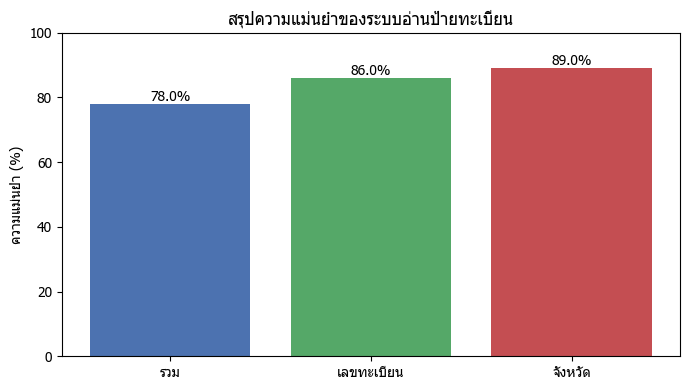

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
labels = ["รวม", "เลขทะเบียน", "จังหวัด"]
values = [acc_overall, acc_plate, acc_province]
bars = ax.bar(labels, values, color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylim(0, 100)
ax.set_ylabel("ความแม่นยำ (%)")
ax.set_title("สรุปความแม่นยำของระบบอ่านป้ายทะเบียน")
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()


### 6.1 กราฟความมั่นใจเฉลี่ย (Average Confidence)


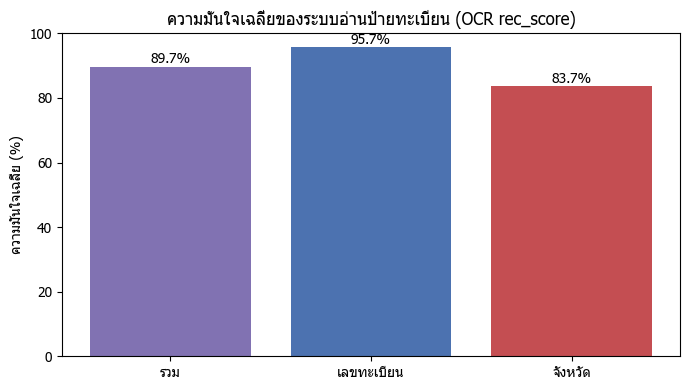

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
labels = ["รวม", "เลขทะเบียน", "จังหวัด"]
values = [avg_confidence_overall, avg_plate_confidence, avg_province_confidence]
bars = ax.bar(labels, values, color=["#8172B2", "#4C72B0", "#C44E52"])
ax.set_ylim(0, 100)
ax.set_ylabel("ความมั่นใจเฉลี่ย (%)")
ax.set_title("ความมั่นใจเฉลี่ยของระบบอ่านป้ายทะเบียน (OCR rec_score)")
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()


## 7. วิเคราะห์ตัวอักษร/ตัวเลขที่ระบบทายผิดบ่อย (Confusion Analysis)

สำหรับภาพที่เลขทะเบียนทายผิด จะใช้การจัดตำแหน่งด้วย Levenshtein Edit Distance เพื่อเทียบตัวอักษรจริง (Ground Truth) กับตัวอักษรที่ระบบทาย (Predicted) ทีละตำแหน่ง แล้วนับเฉพาะกรณี **แทนที่ (substitution)** คือกรณีที่ตำแหน่งเดียวกันมีตัวอักษรจริงเป็นตัวหนึ่ง แต่ระบบทายเป็นอีกตัวหนึ่ง

$$\text{count}(a \rightarrow b) = \sum_{i=1}^{N} \mathbb{1}\left[ \text{ตำแหน่งหนึ่งในการจัดเรียงของภาพที่ } i \text{ มีตัวจริง} = a \text{ และตัวที่ทาย} = b \right]$$

โดย $\mathbb{1}[\cdot]$ คือฟังก์ชันตัวชี้วัด (indicator function) มีค่าเท่ากับ 1 เมื่อเงื่อนไขในวงเล็บเป็นจริง และเท่ากับ 0 เมื่อเป็นเท็จ ผลลัพธ์ $\text{count}(a \rightarrow b)$ คือจำนวนครั้งที่ตัวอักษรจริง $a$ ถูกทายผิดเป็นตัวอักษร $b$ ตลอดชุดข้อมูลทดสอบ


In [10]:
def get_substitution_pairs(expected: str, predicted: str):
    """คืนรายการคู่ (ตัวจริง, ตัวที่ทายผิดเป็น) จากตำแหน่งที่ถูก 'แทนที่' ตาม Levenshtein alignment"""
    pairs = []
    ops = Levenshtein.editops(expected, predicted)
    for op, src_pos, dst_pos in ops:
        if op == "replace":
            pairs.append((expected[src_pos], predicted[dst_pos]))
    return pairs


confusion_counter = Counter()
for e, p in zip(df["expected_plate"], df["predicted_plate"]):
    if e == p:
        continue
    for pair in get_substitution_pairs(e, p):
        confusion_counter[pair] += 1

confusion_df = pd.DataFrame(
    [(a, b, c) for (a, b), c in confusion_counter.items()],
    columns=["ตัวจริง", "ตัวที่ทายผิดเป็น", "จำนวนครั้ง"],
).sort_values("จำนวนครั้ง", ascending=False).reset_index(drop=True)

confusion_df.head(20)


,ตัวจริง,ตัวที่ทายผิดเป็น,จำนวนครั้ง
0,ฏ,ฎ,2
1,ช,ข,2
2,8,6,1
3,5,6,1
4,ซ,ข,1
5,ม,ผ,1


### 7.1 กราฟคู่ตัวอักษรที่ทายผิดบ่อยที่สุด


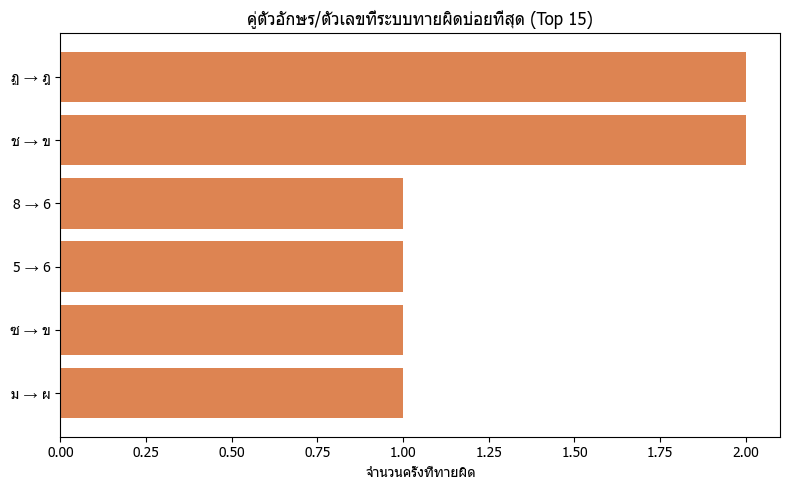

In [11]:
top_n = confusion_df.head(15).copy()
top_n["คู่"] = top_n["ตัวจริง"] + " → " + top_n["ตัวที่ทายผิดเป็น"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_n["คู่"][::-1], top_n["จำนวนครั้ง"][::-1], color="#DD8452")
ax.set_xlabel("จำนวนครั้งที่ทายผิด")
ax.set_title("คู่ตัวอักษร/ตัวเลขที่ระบบทายผิดบ่อยที่สุด (Top 15)")
plt.tight_layout()
plt.show()


### 7.2 Confusion Matrix ระดับตัวอักษร/ตัวเลข


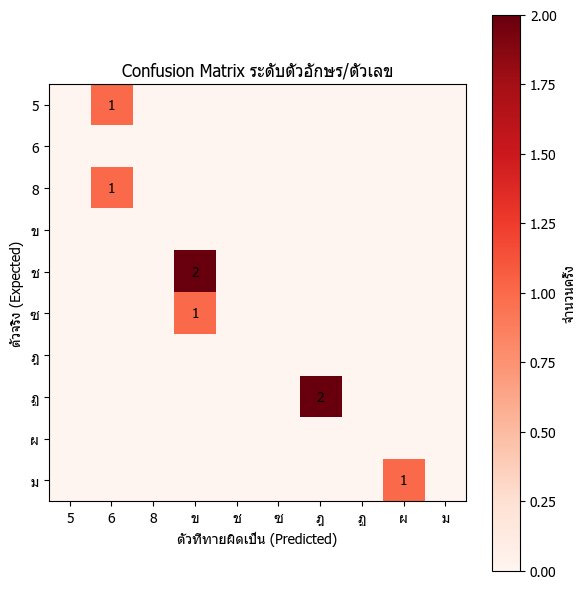

In [12]:
chars_involved = sorted(set(confusion_df["ตัวจริง"]) | set(confusion_df["ตัวที่ทายผิดเป็น"]))

if chars_involved:
    matrix = pd.DataFrame(0, index=chars_involved, columns=chars_involved)
    for _, row in confusion_df.iterrows():
        matrix.loc[row["ตัวจริง"], row["ตัวที่ทายผิดเป็น"]] = row["จำนวนครั้ง"]

    fig, ax = plt.subplots(figsize=(max(6, len(chars_involved) * 0.6), max(6, len(chars_involved) * 0.6)))
    im = ax.imshow(matrix.values, cmap="Reds")
    ax.set_xticks(range(len(chars_involved)))
    ax.set_xticklabels(chars_involved)
    ax.set_yticks(range(len(chars_involved)))
    ax.set_yticklabels(chars_involved)
    ax.set_xlabel("ตัวที่ทายผิดเป็น (Predicted)")
    ax.set_ylabel("ตัวจริง (Expected)")
    ax.set_title("Confusion Matrix ระดับตัวอักษร/ตัวเลข")
    for i in range(len(chars_involved)):
        for j in range(len(chars_involved)):
            v = matrix.values[i, j]
            if v > 0:
                ax.text(j, i, int(v), ha="center", va="center", color="black")
    fig.colorbar(im, ax=ax, label="จำนวนครั้ง")
    plt.tight_layout()
    plt.show()
else:
    print("✅ ไม่พบการทายผิดระดับตัวอักษร (เลขทะเบียนถูกทุกภาพ หรือความยาวไม่ตรงกันทั้งหมด)")


## 8. วิเคราะห์จังหวัดที่ระบบทายผิดบ่อย

นับจำนวนครั้งที่จังหวัดจริง (Expected Province) ถูกทายผิดเป็นจังหวัดอื่น (Predicted Province) ในแต่ละคู่


In [13]:
province_confusion = Counter()
for e, p in zip(df["expected_province"], df["predicted_province"]):
    if e != p:
        province_confusion[(e, p if p else "ไม่พบจังหวัด")] += 1

province_confusion_df = pd.DataFrame(
    [(a, b, c) for (a, b), c in province_confusion.items()],
    columns=["จังหวัดจริง", "จังหวัดที่ทายผิดเป็น", "จำนวนครั้ง"],
).sort_values("จำนวนครั้ง", ascending=False).reset_index(drop=True)

province_confusion_df.head(20)


,จังหวัดจริง,จังหวัดที่ทายผิดเป็น,จำนวนครั้ง
0,ขอนแก่น,ไม่พบจังหวัด,7
1,กรุงเทพมหานคร,ไม่พบจังหวัด,2
2,มหาสารคาม,ไม่พบจังหวัด,1
3,ขอนแก่น,นครราชสีมา,1


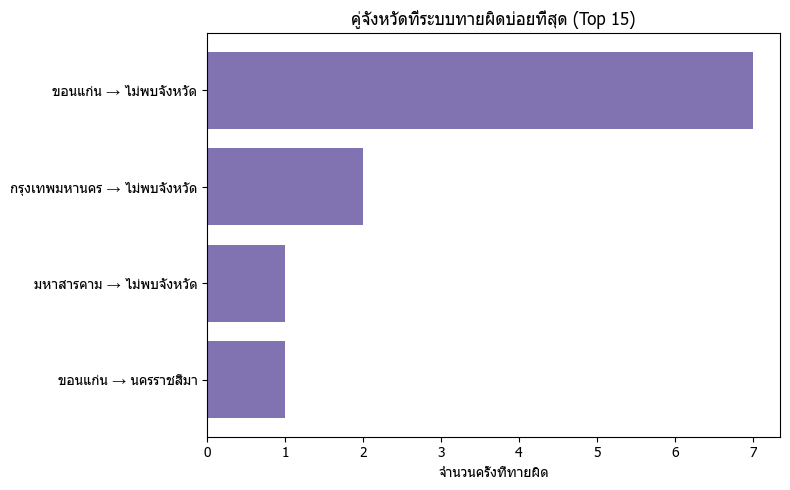

In [14]:
if not province_confusion_df.empty:
    top_prov = province_confusion_df.head(15).copy()
    top_prov["คู่"] = top_prov["จังหวัดจริง"] + " → " + top_prov["จังหวัดที่ทายผิดเป็น"]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(top_prov["คู่"][::-1], top_prov["จำนวนครั้ง"][::-1], color="#8172B2")
    ax.set_xlabel("จำนวนครั้งที่ทายผิด")
    ax.set_title("คู่จังหวัดที่ระบบทายผิดบ่อยที่สุด (Top 15)")
    plt.tight_layout()
    plt.show()
else:
    print("✅ ไม่พบการทายจังหวัดผิดเลย")


## 9. บันทึกผลลัพธ์ทั้งหมดเป็นไฟล์


In [15]:
OUTPUT_DIR = Path("eval_output")
OUTPUT_DIR.mkdir(exist_ok=True)

df.to_csv(OUTPUT_DIR / "eval_details.csv", index=False, encoding="utf-8-sig")
summary.to_csv(OUTPUT_DIR / "eval_summary.csv", index=False, encoding="utf-8-sig")
confusion_df.to_csv(OUTPUT_DIR / "char_confusion.csv", index=False, encoding="utf-8-sig")
province_confusion_df.to_csv(OUTPUT_DIR / "province_confusion.csv", index=False, encoding="utf-8-sig")

print("✅ บันทึกผลลัพธ์ทั้งหมดที่โฟลเดอร์:", OUTPUT_DIR.resolve())


✅ บันทึกผลลัพธ์ทั้งหมดที่โฟลเดอร์: D:\license_plate_and_car_detection\program\analysis\eval_output
